## Homework 2: Stochastic Gradient Descent

### Exercise 4: An ML Project with SGD

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv("insurance.csv")

features = ["age", "bmi", "children"]
target = "charges"

X = df[features].values.astype(float)
y = df[target].values.astype(float)
df = df.drop(['sex', 'smoker', 'region', 'charges'], axis = 1)

N, d = X.shape

display(df)

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


In [ ]:
# Standardize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# Standardize target
y_mean = y.mean()
y_std = y.std()
y = (y - y_mean) / y_std

In [15]:
# shape: (N, d+1)
X = np.hstack([np.ones((N, 1)), X])
d = X.shape[1]

In [18]:
def L(theta, X, y):
    preds = X @ theta
    return np.mean((preds - y) ** 2)

def grad_L(theta, X, y):
    preds = X @ theta
    return (2 / len(y)) * X.T @ (preds - y)

In [19]:
def gradient_descent(
    X, y, theta0, eta=1e-2, max_epochs=200, tol_grad=1e-6
):
    theta = theta0.copy()
    losses = []
    grad_norms = []

    for epoch in range(max_epochs):
        g = grad_L(theta, X, y)
        grad_norm = np.linalg.norm(g)

        losses.append(L(theta, X, y))
        grad_norms.append(grad_norm)

        if grad_norm < tol_grad:
            break

        theta -= eta * g

    return theta, losses, grad_norms


In [ ]:
def SGD(X, y, theta0, eta=1e-2, batch_size=10, epochs=200):
    theta = theta0.copy()
    losses = []
    grad_norms = []

    N = len(y)

    for _ in range(epochs):
        idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = idx[start:start + batch_size]
            g = grad_L(theta, X[batch_idx], y[batch_idx])
            theta -= eta * g

        losses.append(L(theta, X, y))
        grad_norms.append(np.linalg.norm(grad_L(theta, X, y)))

    return theta, losses, grad_norms

In [23]:
eta = 1e-2
epochs = 200
theta0 = np.zeros(d)

batch_sizes = [1, 10, 50]

In [25]:
theta_gd, loss_gd, gradnorm_gd = gradient_descent(
    X, y, theta0, eta=eta, max_epochs=epochs
)

In [26]:
results_sgd = {}

for bs in batch_sizes:
    theta_sgd, loss_sgd, gradnorm_sgd = SGD(
        X, y, theta0, eta=eta, batch_size=bs, epochs=epochs
    )
    results_sgd[bs] = (theta_sgd, loss_sgd, gradnorm_sgd)

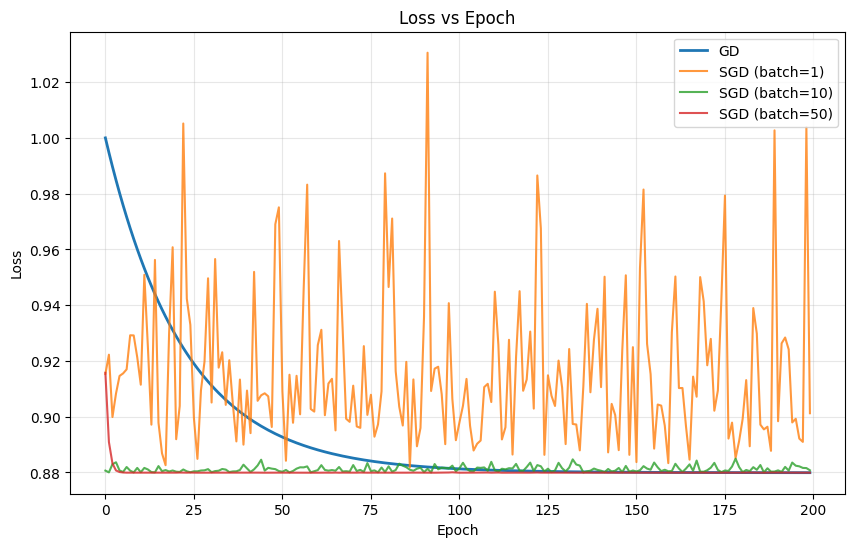

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(loss_gd, label="GD", linewidth=2)

for bs in batch_sizes:
    plt.plot(results_sgd[bs][1], label=f"SGD (batch={bs})", alpha=0.8)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


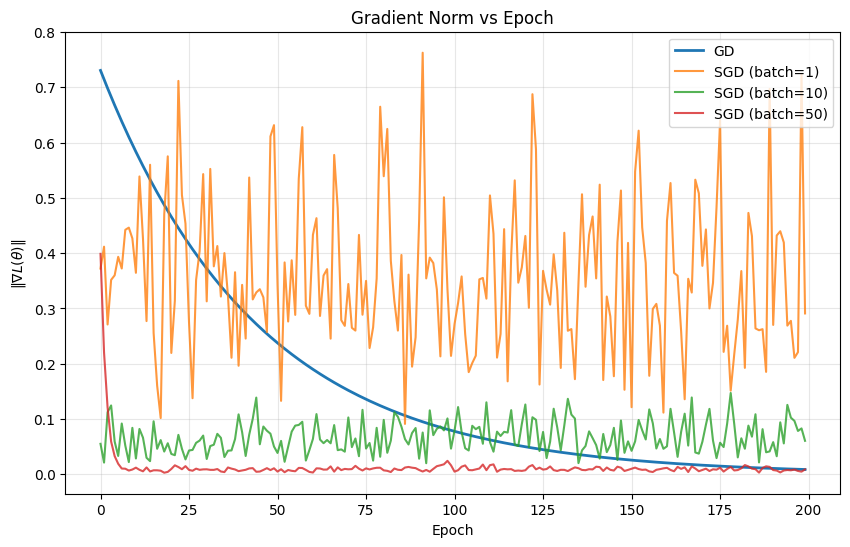

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(gradnorm_gd, label="GD", linewidth=2)

for bs in batch_sizes:
    plt.plot(results_sgd[bs][2], label=f"SGD (batch={bs})", alpha=0.8)

plt.xlabel("Epoch")
plt.ylabel(r"$\|\nabla L(\theta)\|$")
plt.title("Gradient Norm vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [30]:
print("Final parameters:\n")

print("GD:")
print(theta_gd, "\n")

for bs in batch_sizes:
    print(f"SGD (batch={bs}):")
    print(results_sgd[bs][0], "\n")


Final parameters:

GD:
[6.01949046e-18 2.74489295e-01 1.66247193e-01 5.39419420e-02] 

SGD (batch=1):
[-0.09863967  0.38618927  0.15071924  0.06112186] 

SGD (batch=10):
[-0.02033772  0.27144523  0.1521954   0.04159933] 

SGD (batch=50):
[-0.00213627  0.27550495  0.16585031  0.0525368 ] 

